# Прогноз объема обращений

Ноутбук показывает постановку задачи, признаки, baseline и интерпретацию прогноза для планирования смен.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

root = Path('..')
processed = root / 'data' / 'processed'
marts = root / 'data' / 'marts'

## Подготовка дневного ряда

Агрегируем тикеты по дате создания и добавляем календарные признаки.

In [2]:
tickets = pd.read_csv(processed / 'tickets.csv', parse_dates=['created_at'])
daily = tickets.assign(date=tickets['created_at'].dt.date).groupby('date').size().rename('actual_tickets').reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily['day_of_week'] = daily['date'].dt.dayofweek + 1
daily['month'] = daily['date'].dt.month
daily['is_weekend'] = (daily['day_of_week'] >= 6).astype(int)
daily.head()

,date,actual_tickets,day_of_week,month,is_weekend
0,2025-10-01,27,3,10,0
1,2025-10-02,28,4,10,0
2,2025-10-03,20,5,10,0
3,2025-10-04,12,6,10,1
4,2025-10-05,10,7,10,1


In [3]:
daily['lag_1'] = daily['actual_tickets'].shift(1)
daily['lag_7'] = daily['actual_tickets'].shift(7)
daily['rolling_7_mean'] = daily['actual_tickets'].shift(1).rolling(7).mean()
model_data = daily.dropna().copy()
model_data.tail()

,date,actual_tickets,day_of_week,month,is_weekend,lag_1,lag_7,rolling_7_mean
238,2026-05-27,28,3,5,0,30.0,30.0,24.857143
239,2026-05-28,25,4,5,0,28.0,25.0,24.571429
240,2026-05-29,35,5,5,0,25.0,27.0,24.571429
241,2026-05-30,7,6,5,1,35.0,11.0,25.714286
242,2026-05-31,12,7,5,1,7.0,15.0,25.142857


## Baseline и модель

Сравниваем модель со скользящим средним за семь дней.

In [4]:
test_days = 28
features = ['day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_7', 'rolling_7_mean']
train = model_data.iloc[:-test_days]
test = model_data.iloc[-test_days:]

model = RandomForestRegressor(n_estimators=150, random_state=42, max_depth=6)
model.fit(train[features], train['actual_tickets'])
test = test.copy()
test['model_forecast'] = model.predict(test[features])
test['moving_average_forecast'] = test['rolling_7_mean']

mae_model = mean_absolute_error(test['actual_tickets'], test['model_forecast'])
mape_model = mean_absolute_percentage_error(test['actual_tickets'], test['model_forecast']) * 100
mae_baseline = mean_absolute_error(test['actual_tickets'], test['moving_average_forecast'])
mape_baseline = mean_absolute_percentage_error(test['actual_tickets'], test['moving_average_forecast']) * 100
mae_model, mape_model, mae_baseline, mape_baseline

(3.6211279095902236, 18.950314206867866, 7.658163265306122, 49.5809169992387)

## Визуализация

Смотрим факт, прогноз модели и baseline на тестовом периоде.

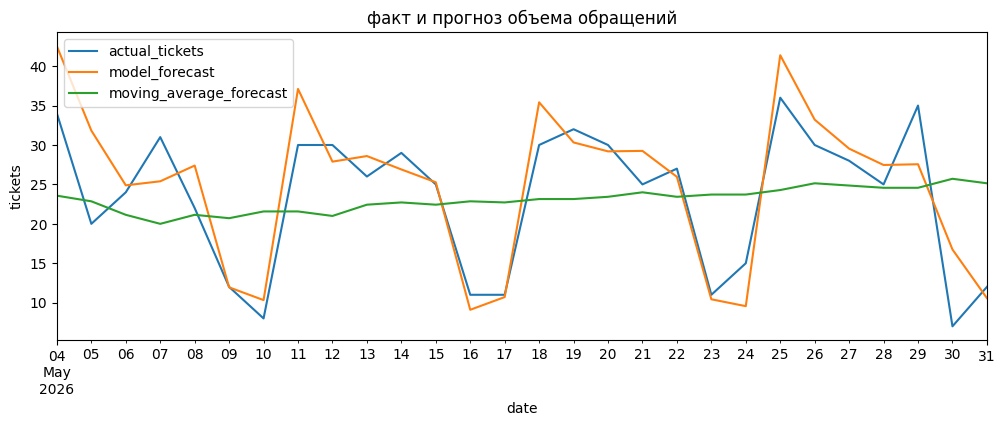

In [5]:
plot_data = test.set_index('date')[['actual_tickets', 'model_forecast', 'moving_average_forecast']]
plot_data.plot(figsize=(12, 4))
plt.title('факт и прогноз объема обращений')
plt.ylabel('tickets')
plt.show()

## Бизнес-интерпретация

Прогноз помогает заранее планировать смены первой линии, проверять риск роста backlog и готовить резерв на дни после инцидентов или релизов.

## Ограничения

Модель не знает о релизах, маркетинговых кампаниях, праздниках и внешних инцидентах. для промышленного прогноза эти факторы нужно добавить отдельными признаками.

In [6]:
forecast_mart = pd.read_csv(marts / 'mart_forecast.csv')
forecast_mart.tail(20)

,date,actual_tickets,day_of_week,month,is_weekend,lag_1,lag_7,rolling_7_mean,model_forecast,moving_average_forecast,dataset_split,absolute_error
237,2026-05-26,30.0,2,2026-05,0,36,32,25.14,31.06,25.14,test,1.06
238,2026-05-27,28.0,3,2026-05,0,30,30,24.86,28.12,24.86,test,0.12
239,2026-05-28,25.0,4,2026-05,0,28,25,24.57,28.27,24.57,test,3.27
240,2026-05-29,35.0,5,2026-05,0,25,27,24.57,25.02,24.57,test,9.98
241,2026-05-30,7.0,6,2026-05,1,35,11,25.71,13.85,25.71,test,6.85
242,2026-05-31,12.0,7,2026-05,1,7,15,25.14,11.89,25.14,test,0.11
243,2026-06-01,NaN,1,2026-06,0,12,36,24.71,40.00,25.00,future,NaN
244,2026-06-02,NaN,2,2026-06,0,40,30,25.29,32.00,25.00,future,NaN
245,2026-06-03,NaN,3,2026-06,0,32,28,25.57,29.00,26.00,future,NaN
246,2026-06-04,NaN,4,2026-06,0,29,25,25.71,29.00,26.00,future,NaN
